# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [7]:
import pandas as pd

df = pd.read_csv('/content/airbnb_listings (5).csv')
display(df.head())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,host_url,host_name,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20250804133828,2025-08-04,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://www.airbnb.com/users/show/4621559,Kenneth,...,4.56,3.22,3.67,NaN,0,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20250804133828,2025-08-04,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://www.airbnb.com/users/show/19648678,Terra,...,4.81,4.81,4.77,NaN,0,4,4,0,0,2.32
2,5651579,https://www.airbnb.com/rooms/5651579,20250804133828,2025-08-04,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://www.airbnb.com/users/show/29288920,Gregg,...,4.88,4.76,4.64,NaN,0,2,1,1,0,2.97
3,6623339,https://www.airbnb.com/rooms/6623339,20250804133828,2025-08-04,city scrape,Bright & Cozy City Stay · Top Location + Parking!,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://www.airbnb.com/users/show/19648678,Terra,...,4.70,4.80,4.72,NaN,0,4,4,0,0,2.68
4,9005989,https://www.airbnb.com/rooms/9005989,20250804133828,2025-08-04,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://www.airbnb.com/users/show/17766924,Sugey,...,4.93,4.87,4.77,NaN,0,1,1,0,0,5.67


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



Original 'price' column distribution:


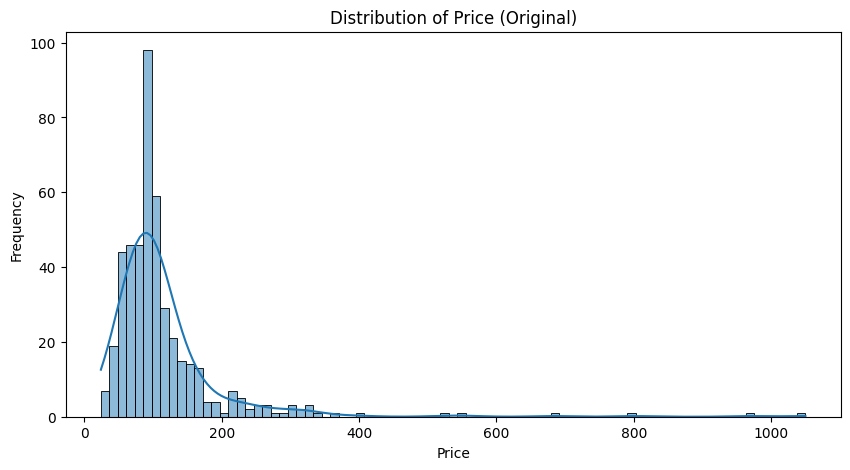


Transformed 'price_log' column distribution (if applied):


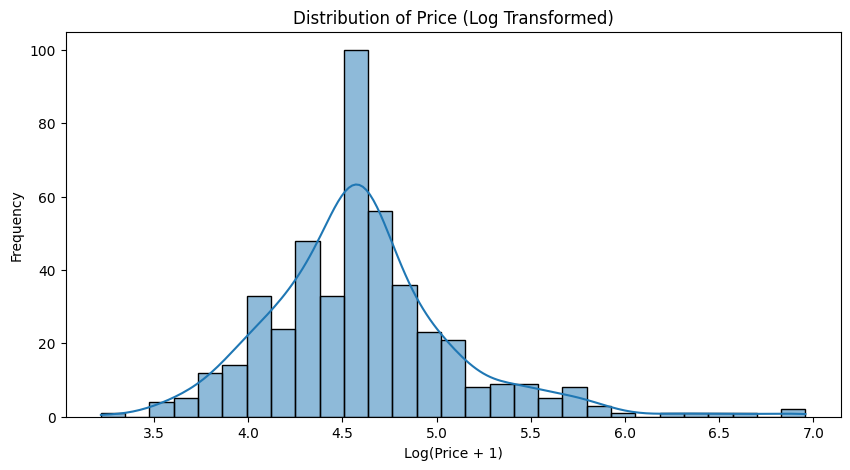

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Choose a numeric column: 'price' is often skewed
print("Original 'price' column distribution:")
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True)
plt.title("Distribution of Price (Original)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Consider applying a log transformation to reduce skewness
# You can try this by uncommenting and running the following lines
df['price_log'] = np.log1p(df['price']) # Using log1p to handle zero values gracefully

print("\nTransformed 'price_log' column distribution (if applied):")
plt.figure(figsize=(10, 5))
sns.histplot(df['price_log'], kde=True)
plt.title("Distribution of Price (Log Transformed)")
plt.xlabel("Log(Price + 1)")
plt.ylabel("Frequency")
plt.show()

### ✍️ Your Response: 🔧
1. I analyzed the price column, and skewed right.

2. I did the log transformation for reducing the skewness, and making balance of data.

3. After the log transformation, the right-skewed graph found the balance, and became the normal distribution. This made to read and and understand easier.



## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [13]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Choose two numeric columns: 'price' and 'minimum_nights'
# 'price' often has a larger range, 'minimum_nights' can also vary

# Initialize scalers
min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

# Min-Max scale 'price' to a range of 0-1
# Reshape the data for the scaler (-1, 1) means unknown number of rows, 1 column
df['price_minmax_scaled'] = min_max_scaler.fit_transform(df[['price']])

# Z-score scale 'minimum_nights'
df['minimum_nights_zscore_scaled'] = standard_scaler.fit_transform(df[['minimum_nights']])

# Display the head of the DataFrame with the new columns
display(df[['price', 'price_minmax_scaled', 'minimum_nights', 'minimum_nights_zscore_scaled']].head())

,price,price_minmax_scaled,minimum_nights,minimum_nights_zscore_scaled
0,70.0,0.044834,28,1.068715
1,104.0,0.077973,2,-0.237784
2,75.0,0.049708,2,-0.237784
3,101.0,0.075049,2,-0.237784
4,110.0,0.083821,1,-0.288034


### ✍️ Your Response: 🔧
1. I scaled price and minimum night. For the price, I made each price from 0 to 1, and used z-score standardization, to make average as 0, and standard deviation as 1.

2. Scaling is good for comparing variables or using for machine learning.

3. Data analyst or Price maker would use it effectively, since it is available that they can compare data in same criteria.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [15]:
# Choose 'number_of_reviews' for grouping
# Define bin edges and labels
# Using pd.qcut to get bins with approximately equal numbers of observations
df['review_category'] = pd.qcut(df['number_of_reviews'],
                                  q=3,
                                  labels=['Low', 'Medium', 'High'],
                                  duplicates='drop') # 'drop' handles cases where there are too many identical values

# Display the count of each new category and a sample of the DataFrame
print("Distribution of 'review_category':")
display(df['review_category'].value_counts())
display(df[['number_of_reviews', 'review_category']].head())

Distribution of 'review_category':


,count
review_category,
Medium,156
Low,155
High,148


,number_of_reviews,review_category
0,9,Medium
1,310,High
2,371,High
3,332,High
4,621,High


### ✍️ Your Response: 🔧
1. I grouped 'number of reviews', with three categories, 'low','medium', and 'high'.

2. Grouping in categories is better to understand than raw numbers. For example, in this case, we can understand whether the number of review is low, medium, and high than using raw number and making criteria.

3. Data analyst, and Marketing team would use it effectively. They can compare the customers satisfaction easily, find the great place in the list, and offer owners results.

3.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

In [16]:
import numpy as np

# 1. Create a ratio or interaction between columns: price per night
# Handle cases where 'minimum_nights' might be zero to avoid division by zero
df['price_per_night'] = df['price'] / df['minimum_nights'].replace(0, np.nan)

# 2. Create a flag based on a condition: stays longer than 30 days
df['is_long_stay'] = df['minimum_nights'] > 30

# Display the head of the DataFrame with the new columns
display(df[['price', 'minimum_nights', 'price_per_night', 'is_long_stay']].head())

,price,minimum_nights,price_per_night,is_long_stay
0,70.0,28,2.5,False
1,104.0,2,52.0,False
2,75.0,2,37.5,False
3,101.0,2,50.5,False
4,110.0,1,110.0,False


### ✍️ Your Response: 🔧 🔧
1. I made two new columns, price_per_night, and is_long_stay.

2. Airbnb host, manager, and operation team can use it.

3. In the case of price_per_night, it is helpful for finding the average price per night, Also, in the case of is_long_stay, since it shows the place where we can stay long, so it would help for customer targeting, and calculating best price range.



## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [18]:
# Choose a categorical column: 'room_type'
# Apply one-hot encoding using pandas get_dummies
room_type_encoded = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int)

# Add the new encoded columns to the DataFrame
df = pd.concat([df, room_type_encoded], axis=1)

# Display the head of the DataFrame with the original and new encoded columns
# Dynamically select the newly created encoded columns to avoid KeyError
display(df[['room_type'] + list(room_type_encoded.columns)].head())

,room_type,room_type_Entire home/apt,room_type_Entire home/apt,room_type_Private room,room_type_Private room
0,Entire home/apt,1,1,0,0
1,Entire home/apt,1,1,0,0
2,Entire home/apt,1,1,0,0
3,Entire home/apt,1,1,0,0
4,Entire home/apt,1,1,0,0


### ✍️ Your Response: 🔧
1. I encoded room_type. Since it is categorial text data, I changed it for using for machine learning.
2.I used one-hot-coding by using pd.get_dummies() and change those text to 0/1.
3. We can use it for analyzing price in category, and pattern for reservation.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [19]:
df.to_csv("cleaned_airbnb_data_7.csv", index=False)

## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. For me, log transformation was the most interesting thing since it change the skewed result to the normal distribution.

2. Including the column of review_category would work best. Because of this, host can get result their place and compare it, analyst can analyze the newest trend of booking accomodation, and city planner can see the place where lots of people usually visit.

3. After this, I would like to make dashboard of comparing data of review result and other things which are included in this chapter, for showing the analysis and making the decision.

4. Since I am the admiring Supply chain students, focusing on logistics (third-party logistics) I can analyze the data by balancing them, adding the review of each delivery or contract, and making real decision for futher delivery strategy.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_07_data_transformation.ipynb"